#1.Introduction



In [2]:
#Aim and Problem Statement:
print("The aim of this project is to build machine learning models to predict loan default status ('loan_status') based on applicant financial and demographic details.", '\n')

#Target feature selected with discrete values:

print('loan_status (0 = Non-default, 1 = Default).')

The aim of this project is to build machine learning models to predict loan default status ('loan_status') based on applicant financial and demographic details. 

loan_status (0 = Non-default, 1 = Default).


In [3]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#load the dataset
from google.colab import drive
drive.mount('/content/drive')

dataset = pd.read_csv("/content/drive/MyDrive/cse422_project/14.csv")
dataset.head(10) # first 10 ta load korar jnno


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

#2.Dataset Description

In [8]:
# Problem Type:
print("1.Classification problem. Because the target variable 'loan_status' contains discrete categorical outcomes (0 or 1).", '\n')

# Dataset size and Number of features
print('2.Shape of the dataset is {}. This dataset contains {} rows and {} column'.format(dataset.shape, dataset.shape[0], dataset.shape[1]), '\n')

# Types of features in the dataset
numerical_data = dataset.select_dtypes(include='number')
numerical_features = numerical_data.columns.tolist()
print(f'3.There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features, '\n')

categorical_data = dataset.select_dtypes(include='object' )
categorical_features = categorical_data.columns.tolist()
print(f'4.There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features, '\n')





1.Classification problem. Because the target variable 'loan_status' contains discrete categorical outcomes (0 or 1). 

2.Shape of the dataset is (45000, 14). This dataset contains 45000 rows and 14 column 

3.There are 9 numerical features: 

['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status'] 

4.There are 5 categorical features: 

['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file'] 



In [9]:
# Dataset Balance / Imbalance check
class_counts = dataset.groupby("loan_status").size()

columns = ['loan_status', 'count', 'percentage']
outcome = [0, 1]
count = list()
percentage = list()

for val in range(2):
    count.append(class_counts[val])
    percent = (class_counts[val] / len(dataset)) * 100
    percentage.append(percent)

imbalance_df = pd.DataFrame(list(zip(outcome, count, percentage)), columns=columns)
#print(imbalance_df, '\n')
imbalance_df

,loan_status,count,percentage
0,0,35000,77.777778
1,1,10000,22.222222


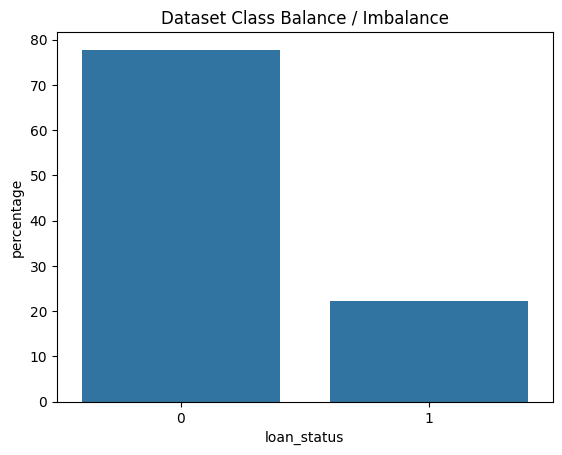

In [10]:
# Represent using a bar chart of N classes
sns.barplot(data=imbalance_df, x=imbalance_df['loan_status'], y=imbalance_df['percentage'])
plt.title('Dataset Class Balance / Imbalance')
plt.show()

#3. Data Analysis

descriptive part

In [11]:
# Numerical Statistics

numerical_data = dataset.select_dtypes(include='number')
numerical_data.describe().T
#print(numerical_data.describe().T, '\n')

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


In [12]:
# Categorical Statistics

categorical_data = dataset.select_dtypes(include='object')
categorical_data.describe().T
#print(categorical_data.describe().T, '\n')

,count,unique,top,freq
person_gender,45000,2,male,24841
person_education,45000,5,Bachelor,13399
person_home_ownership,45000,4,RENT,23443
loan_intent,45000,6,EDUCATION,9153
previous_loan_defaults_on_file,45000,2,Yes,22858


In [13]:
# Variance

numerical_data.var()
#print("Variance:\n", numerical_data.var(), '\n')

,0
person_age,3.654333e+01
person_income,6.467778e+09
person_emp_exp,3.676642e+01
loan_amnt,3.987779e+07
loan_int_rate,8.873299e+00
loan_percent_income,7.605987e-03
cb_person_cred_hist_length,1.505209e+01
credit_score,2.543776e+03
loan_status,1.728433e-01


In [14]:
# Skewness

numerical_data.skew()
#print("Skewness:\n", numerical_data.skew(), '\n')

,0
person_age,2.548154
person_income,34.137583
person_emp_exp,2.594917
loan_amnt,1.179731
loan_int_rate,0.213784
loan_percent_income,1.034512
cb_person_cred_hist_length,1.631720
credit_score,-0.610261
loan_status,1.336351


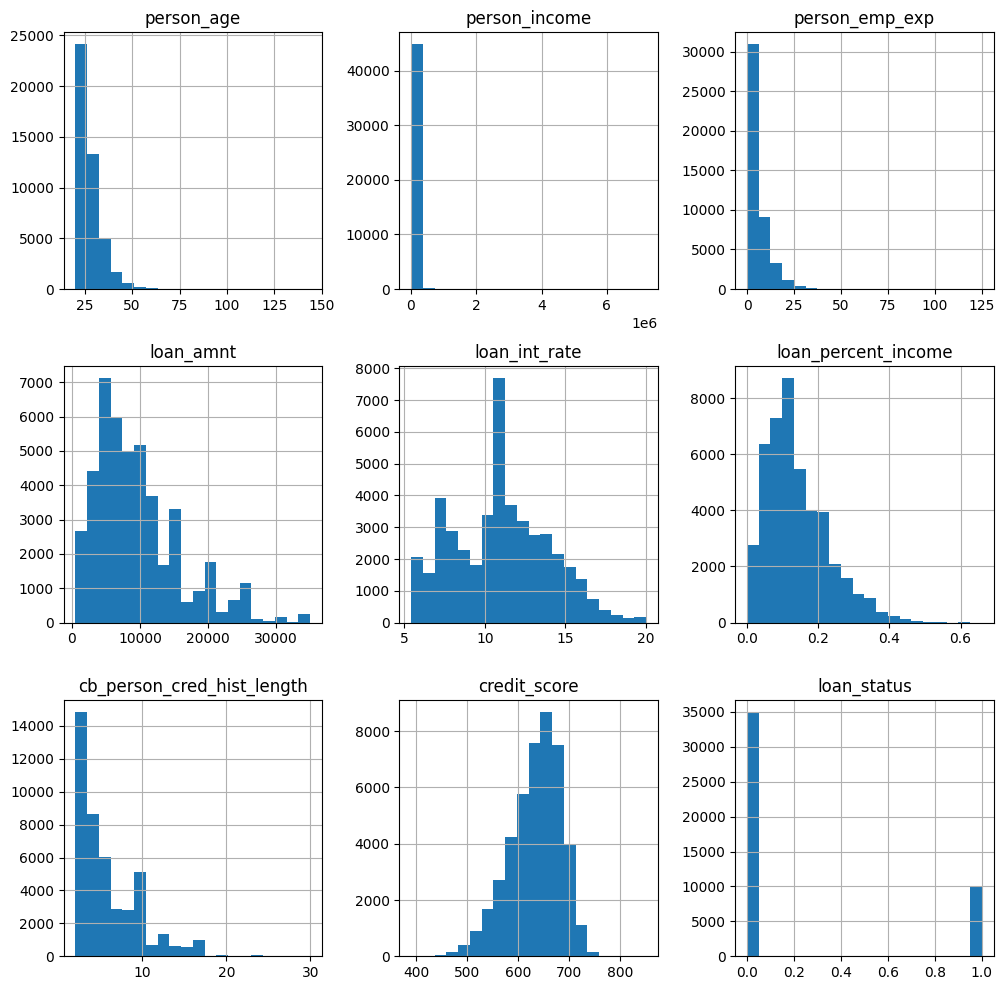

In [15]:
# Histograms -> To find the distributions and outlier in the each feature

numerical_data.hist(figsize=(12, 12), bins=20)
plt.show()

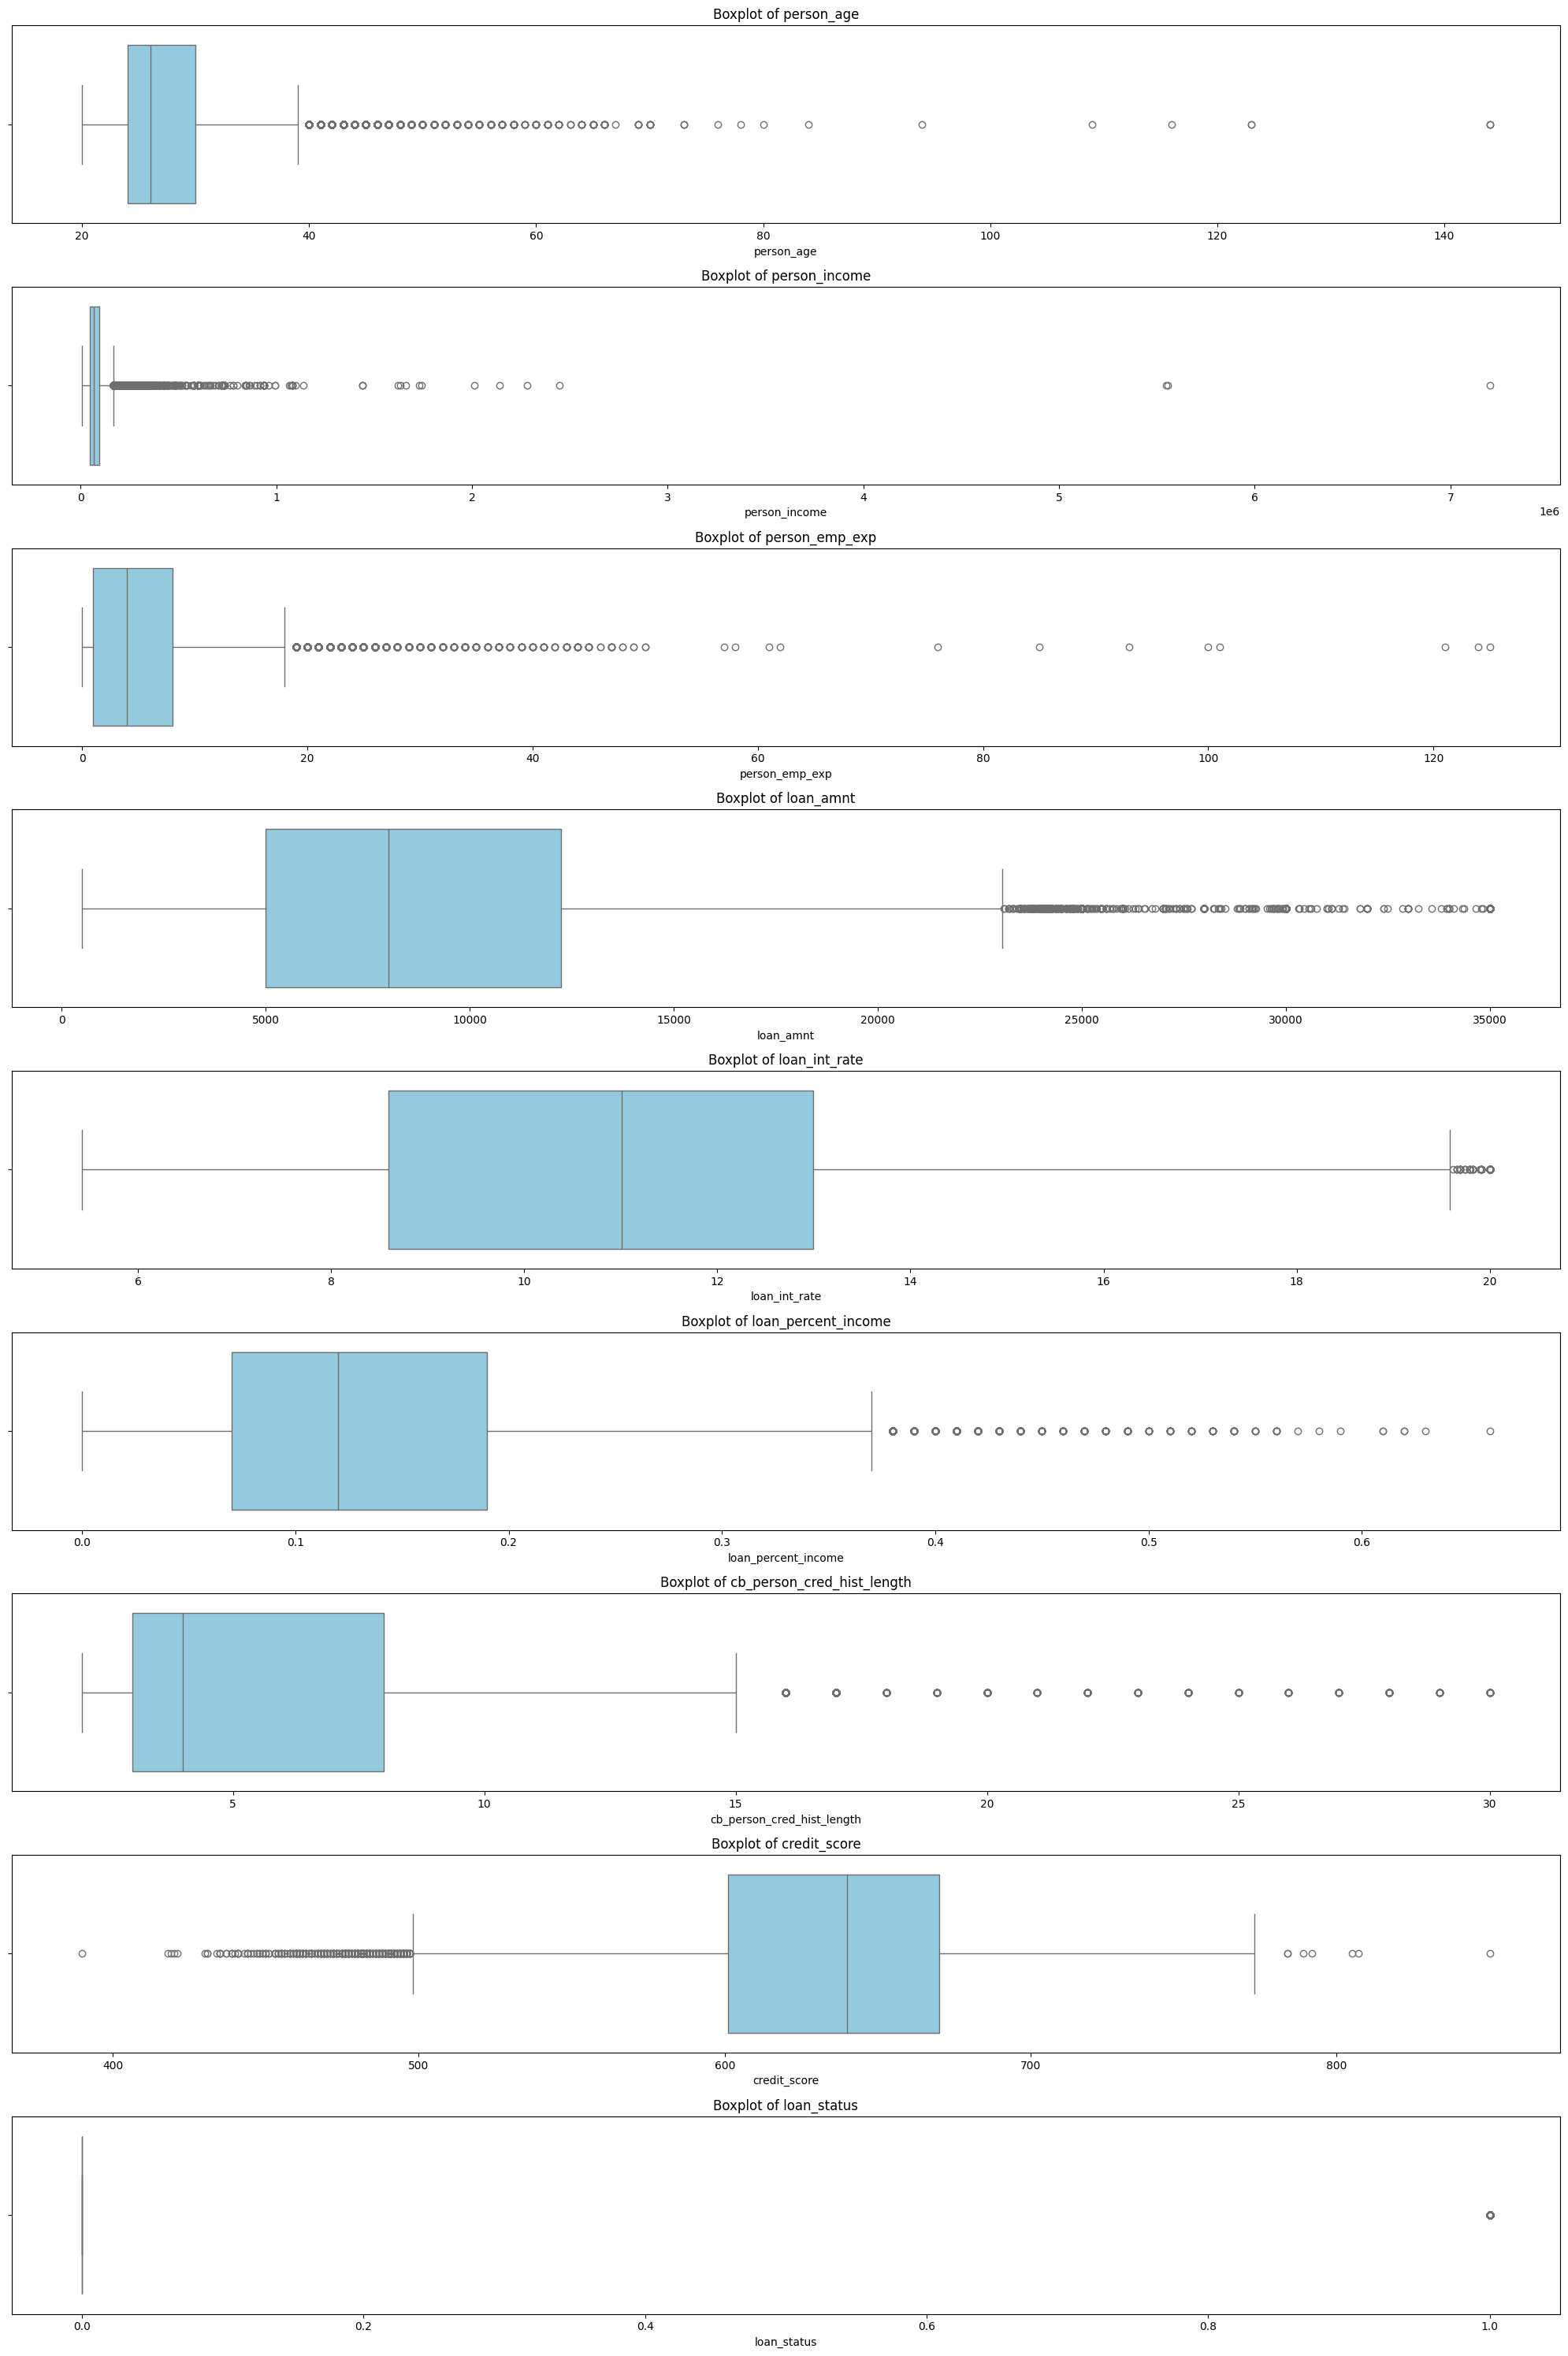

In [16]:
# Boxplots
# Select only numerical columns for boxplot analysis
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(20, 30))
# Plot boxplots for each numerical feature including the target variable 'OUTCOME'
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()
plt.show()

In [17]:
# Number Unique values in each feature
numerical_data.nunique()

,0
person_age,60
person_income,33989
person_emp_exp,63
loan_amnt,4483
loan_int_rate,1302
loan_percent_income,64
cb_person_cred_hist_length,29
credit_score,340
loan_status,2


In [18]:
#Missing Values
numerical_data.isnull().sum()

,0
person_age,0
person_income,0
person_emp_exp,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0
cb_person_cred_hist_length,0
credit_score,0
loan_status,0


catagorical Feature part

In [19]:
# catagorical Features

# unique values counts
unique_counts=categorical_data.nunique()
print(unique_counts)

person_gender                     2
person_education                  5
person_home_ownership             4
loan_intent                       6
previous_loan_defaults_on_file    2
dtype: int64


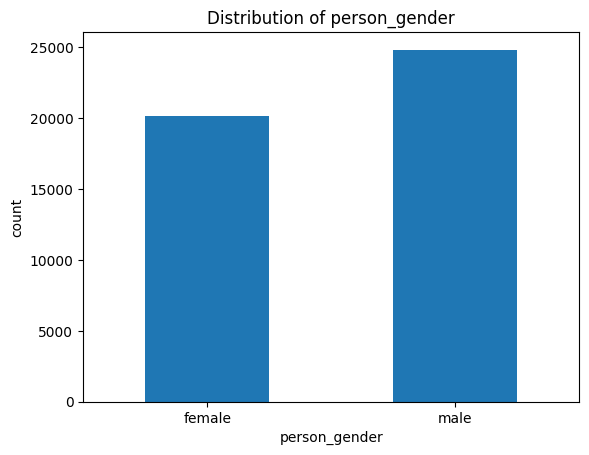

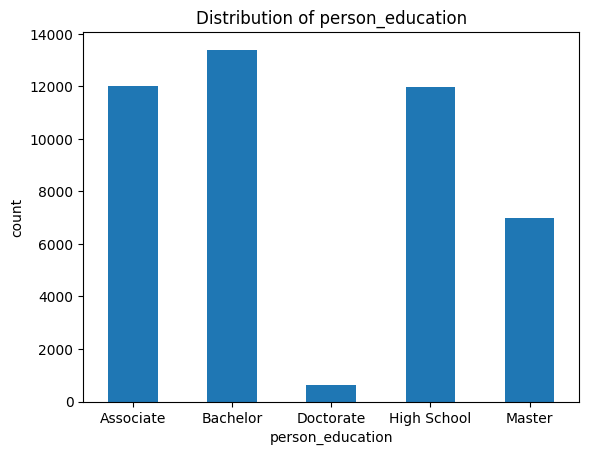

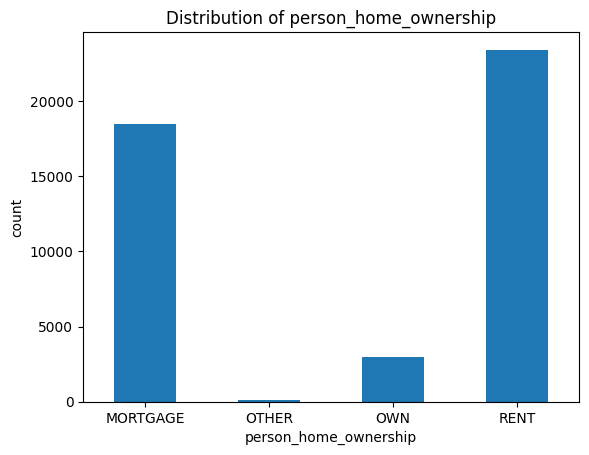

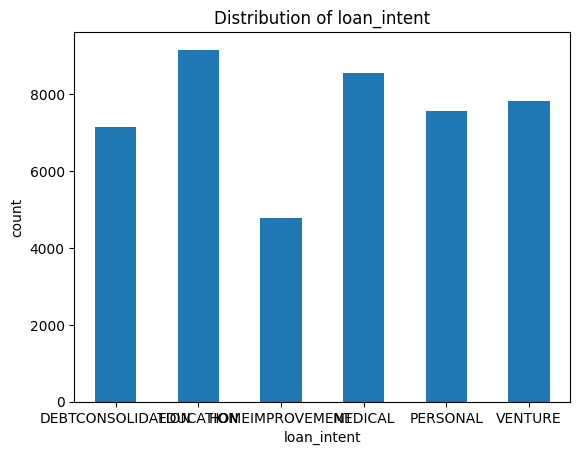

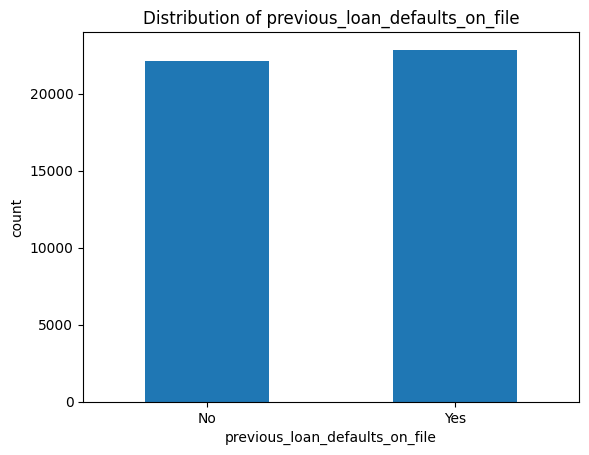

In [20]:
# Distribution of Categorical Features
#Barplot of unique value counts in every categorical features

for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col, ylabel='count')
    plt.show()

Correlation

In [21]:
# Correlation Matrix
correlation_matrix = numerical_data.corr()
correlation_matrix

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
person_age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432,-0.021476
person_income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919,-0.135808
person_emp_exp,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196,-0.020481
loan_amnt,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074,0.107714
loan_int_rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498,0.332005
loan_percent_income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483,0.384880
cb_person_cred_hist_length,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.014851
credit_score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.007647
loan_status,-0.021476,-0.135808,-0.020481,0.107714,0.332005,0.384880,-0.014851,-0.007647,1.000000


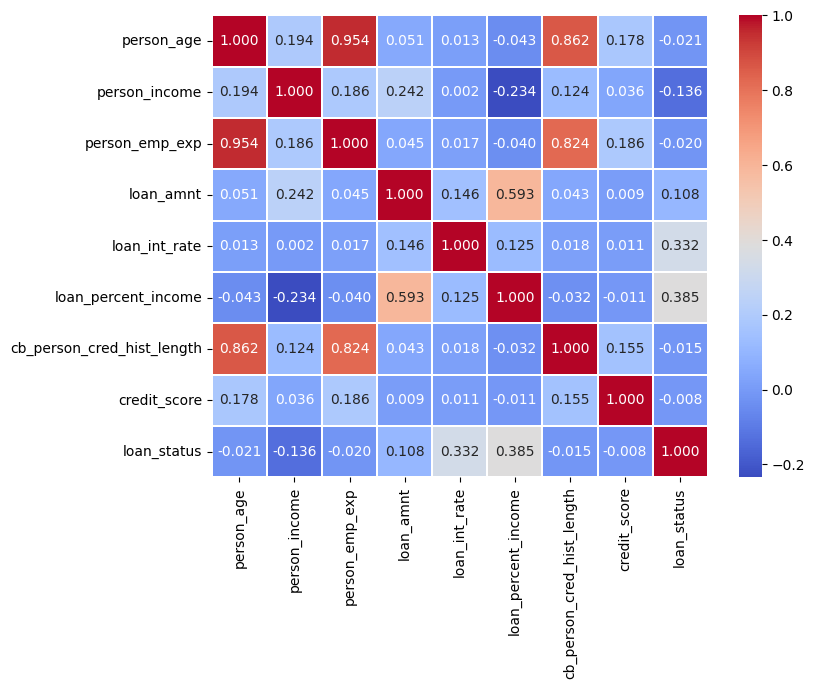

In [22]:
#Heatmap Analysis
## Plotting the heatmap for correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

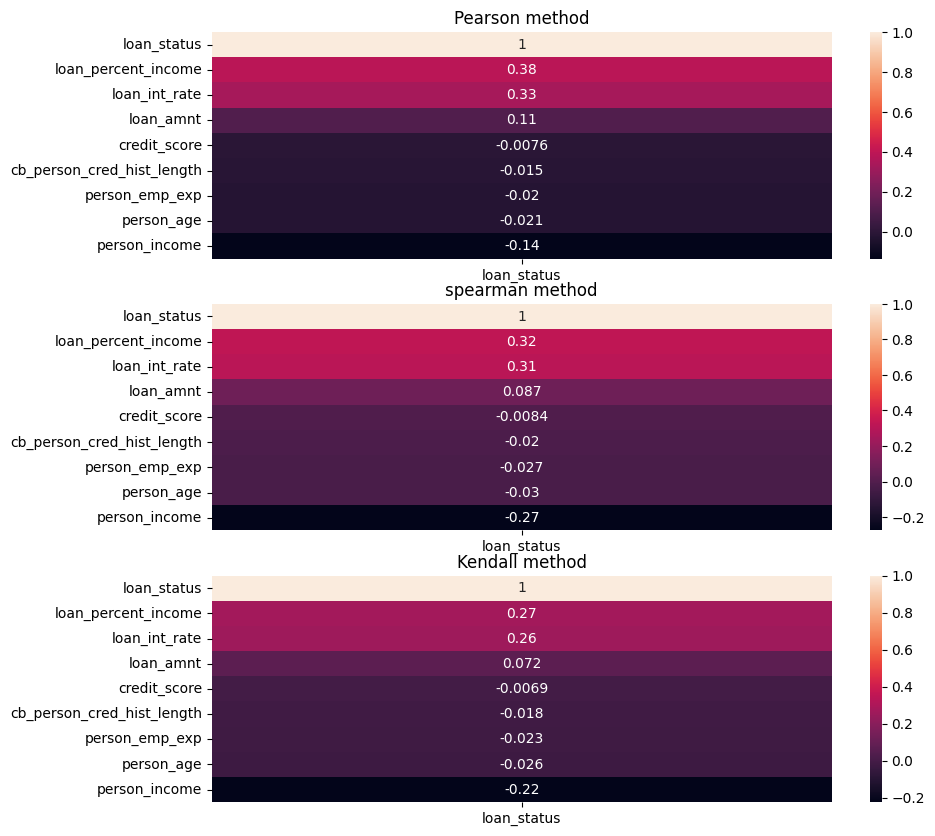

In [23]:
# Correlation with target variable using Pearson, Spearman, Kendall methods

## Correlation coefficient using different methods
fig, ax = plt.subplots(3, 1, figsize=(10, 10))
corr1 = numerical_data.corr('pearson')[['loan_status']].sort_values   (by='loan_status', ascending=False)
corr2 = numerical_data.corr('spearman')[['loan_status']].sort_values(by='loan_status', ascending=False)
corr3 = numerical_data.corr('kendall')[['loan_status']].sort_values(by='loan_status', ascending=False)

#setting titles for each plot
ax[0].set_title('Pearson method')
ax[1].set_title('spearman method')
ax[2].set_title('Kendall method')

## Generating heatmaps of each methods
sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)
plt.show()

# 4. Dataset Pre-processing

1.Handling null values and duplicates

In [24]:
#dataset.isnull().sum()
#dataset.duplicated().sum()
print("Missing values in dataset:",'\n', dataset.isnull().sum(), '\n')
print("Duplicate rows count:", '\n', dataset.duplicated().sum(), '\n')

Missing values in dataset: 
 person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64 

Duplicate rows count: 
 0 



In [25]:
from sklearn.impute import SimpleImputer
import numpy as np

# 1.SimpleImputer object
impute = SimpleImputer(missing_values=np.nan, strategy='mean')

# 2.Fit and transform specific numerical column (e.g., person_age)
impute.fit(dataset[['person_age']])
dataset['person_age'] = impute.transform(dataset[['person_age']])

# 3.Ek-er adhik missing numeric column thakle por por line e likhte hobe:
impute.fit(dataset[['person_income']])
dataset['person_income'] = impute.transform(dataset[['person_income']])

# 4.Updated dataset dekhar jonno
dataset

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


2.Encoding categorical values

In [26]:
from sklearn.preprocessing import LabelEncoder
#Categorical Encoding(option one)-Data with heirarchy/ranking -LabelEncoder()

# 1.Set up the LabelEncoder object
enc = LabelEncoder()

# 2.Apply encoding to a specific column (e.g., loan_intent)
dataset['loan_intent_enc'] = enc.fit_transform(dataset['loan_intent'])

# 3.Compare the two columns
print(dataset[['loan_intent', 'loan_intent_enc']].head())

# 4.Multiple categorical columns-er jonno ekta ekta kore line:

dataset['person_gender'] = enc.fit_transform(dataset['person_gender'])
dataset['person_education'] = enc.fit_transform(dataset['person_education'])
dataset['person_home_ownership'] = enc.fit_transform(dataset['person_home_ownership'])
dataset['loan_intent'] = enc.fit_transform(dataset['loan_intent'])
dataset['previous_loan_defaults_on_file'] = enc.fit_transform(dataset['previous_loan_defaults_on_file'])


  loan_intent  loan_intent_enc
0    PERSONAL                4
1   EDUCATION                1
2     MEDICAL                3
3     MEDICAL                3
4     MEDICAL                3


3.Feature Selection

In [27]:
wine_corr = dataset.corr()
 #dataset er shob numerical columns er moddhe pairwise correlation calculate kore, ar ekta correlation matrix return kore.means- duita variable ekshathe kemon move kore — mane ekta barle onnota bare naki kome.
wine_corr

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,loan_intent_enc
person_age,1.000000,0.017528,-0.014649,0.193698,0.954412,-0.039008,0.050750,0.032005,0.013402,-0.043299,0.861985,0.178432,-0.025917,-0.021476,0.032005
person_gender,0.017528,1.000000,-0.002267,0.010173,0.015078,-0.001172,0.010647,-0.003107,0.003662,-0.000367,0.011999,-0.000223,0.000704,-0.000561,-0.003107
person_education,-0.014649,-0.002267,1.000000,0.000331,-0.012034,-0.000290,-0.002441,0.004356,0.000336,-0.006984,-0.014576,0.012498,-0.002669,-0.001747,0.004356
person_income,0.193698,0.010173,0.000331,1.000000,0.185987,-0.219870,0.242290,0.008639,0.001510,-0.234177,0.124316,0.035919,0.061483,-0.135808,0.008639
person_emp_exp,0.954412,0.015078,-0.012034,0.185987,1.000000,-0.035884,0.044589,0.031230,0.016631,-0.039862,0.824272,0.186196,-0.029231,-0.020481,0.031230
person_home_ownership,-0.039008,-0.001172,-0.000290,-0.219870,-0.035884,1.000000,-0.150243,0.001828,0.130437,0.148933,-0.029549,-0.006421,-0.125974,0.233842,0.001828
loan_amnt,0.050750,0.010647,-0.002441,0.242290,0.044589,-0.150243,1.000000,-0.001068,0.146093,0.593011,0.042969,0.009074,-0.059009,0.107714,-0.001068
loan_intent,0.032005,-0.003107,0.004356,0.008639,0.031230,0.001828,-0.001068,1.000000,-0.005372,0.003269,0.030912,0.016244,0.038469,-0.072158,1.000000
loan_int_rate,0.013402,0.003662,0.000336,0.001510,0.016631,0.130437,0.146093,-0.005372,1.000000,0.125209,0.018008,0.011498,-0.181800,0.332005,-0.005372
loan_percent_income,-0.043299,-0.000367,-0.006984,-0.234177,-0.039862,0.148933,0.593011,0.003269,0.125209,1.000000,-0.031868,-0.011483,-0.203252,0.384880,0.003269


<Axes: >

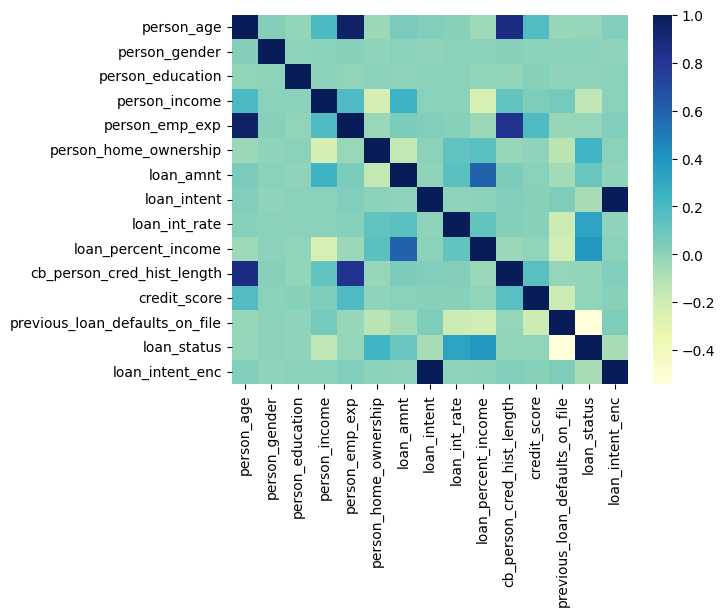

In [28]:
sns.heatmap(wine_corr, cmap = 'YlGnBu')

feature scaling

In [33]:
#using option 2 :StandardScaler
#Dataset e outlier thakar karone Standard Scaler use korছি, karon MinMax outlier-sensitive — outlier thakle shob normal data ekটা choto range e squeeze hoye jay। Standard Scaler mean/std use kore bole eta outlier-এর প্রভাব কম রাখে
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#5. Dataset Splitting

In [32]:
#Dataset Splitting
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = dataset.drop('loan_status', axis=1) #axis=1 = col, axis=0 = row
y = dataset['loan_status']

# Split dataset into 80% Train and 20% Test ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #model traning.ipynb

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training shape: (36000, 14)
Testing shape: (9000, 14)


In [34]:
#testing for indexes
print(X.columns, '\n')
print("Total features:", len(X.columns))

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_intent_enc'],
      dtype='object') 

Total features: 14


#6. Model Training & Testing (Supervised)

You have to apply a Neural Network and at least 2 other models (Total 3 at least, but you are encouraged to do all)

In [35]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

prediction = knn.predict(X_train_scaled)
print("Prediction:", prediction, '\n')

print("Test set score: {:.2f}".format(knn.score(X_test_scaled, y_test)), '\n')

# Training KNN on the scaled training data
knn.fit(X_train_scaled, y_train)

# scoring on the scaled test set
print("KNN test accuracy after Standard Scalar: {:.2f}".format(knn.score(X_test_scaled, y_test)))
#Amar dataset e outlier ache (jemon age=144, income=72 lakh+, jekhane beshirbhag data onek choto range e), tai MinMax use korle shob normal value ekta tight range e squeeze hoye jeto ar model properly distinguish korte parto na. Standard Scaler use koray outlier er effect kom pore ar model better perform kore

Prediction: [0 0 0 ... 0 1 0] 

Test set score: 0.89 

KNN test accuracy after Standard Scalar: 0.89


In [36]:
# Logistic Regression (Classification)
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
print("Logistic Regression Test Accuracy: {:.2f}".format(log_model.score(X_test_scaled, y_test)))


Logistic Regression Test Accuracy: 0.89


In [37]:
# Naive Bayes - from scikit learn
from sklearn.naive_bayes import GaussianNB

# Naive Bayes Model Initialization & Fitting
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

# Evaluation
y_pred_nb = nb.predict(X_test_scaled)
print("Naive Bayes Test Accuracy:", nb.score(X_test_scaled, y_test))

Naive Bayes Test Accuracy: 0.737


In [38]:
# NEural Network
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.losses import SparseCategoricalCrossentropy

# Model

nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    #(Hidden Layer 1), input_shape- dataset er feature gula NN er input hishebe dhore ney
    Dense(32, activation='relu'),#(Hidden Layer 2)
    Dense(2, activation='softmax') #(Output Layer) # Dense-2 er reason loan status er 0 r 1 diye amr predict korte pari tai 2 dewa
])

# Compiling the model
nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Train model
history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=128 #data fast train hoy
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8721 - loss: 0.2803
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8956 - loss: 0.2238
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9005 - loss: 0.2155
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9024 - loss: 0.2103
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9031 - loss: 0.2075
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9049 - loss: 0.2045
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9071 - loss: 0.2023
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9082 - loss: 0.2002
Epoch 9/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9099 - loss: 0.1971
Epoch 10/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9103 - loss: 0.1957


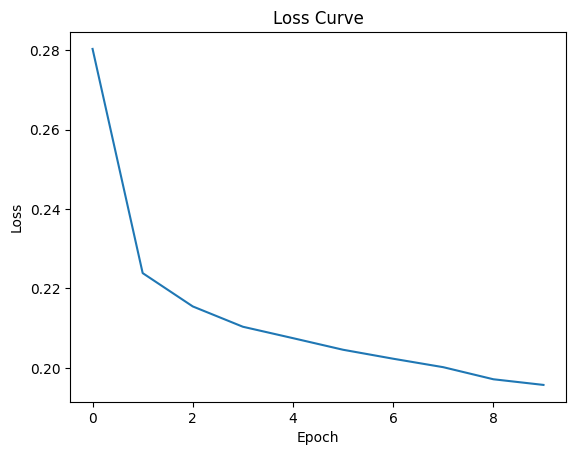

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9084 - loss: 0.2039
---------------------------------------------------------------------------
Neural Network Test Accuracy: 90.84%


In [39]:
# Plot loss curve
plt.plot(history.history['loss'])
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


# Evaluating the model
loss, nn_acc = nn_model.evaluate(X_test_scaled, y_test)
print("---------------------------------------------------------------------------")
print(f"Neural Network Test Accuracy: {round(nn_acc * 100, 2)}%")


#7. Model selection/Comparison analysis

In [40]:
#Precision = What % of predicted positives were actually positive?

#"How accurate are my positive predictions?"

#Recall = What % of actual positives were correctly predicted?

#"How well did I find all the real positives?"

#F1 Score = The balance between precision and recall (harmonic mean).

#"How good is the model overall at finding positives accurately?"

#Formulae:
#Precision = TP / (TP + FP)
#Recall = TP / (TP + FN)
#F1 Score = 2 × (Precision × Recall) / (Precision + Recall)
#Where:

#TP = True Positives
#FP = False Positives
#FN = False Negatives

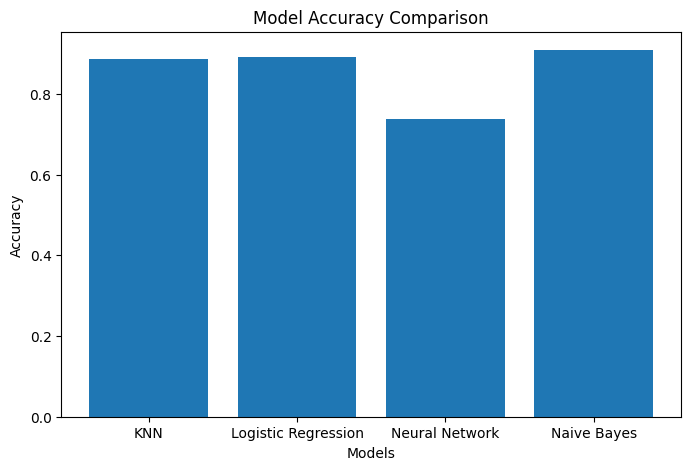

In [41]:
# Bar chart showcasing prediction accuracy of all models (for classification)
from sklearn.metrics import accuracy_score

# Calculating accuracy scores
acc_knn = accuracy_score(y_test, knn.predict(X_test_scaled))
acc_log = accuracy_score(y_test, log_model.predict(X_test_scaled))
acc_nb = accuracy_score(y_test, nb.predict(X_test_scaled))
nn_acc #directly evaluated from CSE422_NeuralNetworkLab.ipynb

models = ['KNN', 'Logistic Regression', 'Neural Network', 'Naive Bayes']
accuracies = [acc_knn, acc_log, acc_nb ,nn_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

In [42]:
# Precision, Recall, F1 Score Comparison
from sklearn.metrics import classification_report

print("--------------------------------- KNN ----------------------------------", '\n')
print(classification_report(y_test, knn.predict(X_test_scaled)), '\n')

print("--------------------------- Logistic Regression -------------------------", '\n')
print(classification_report(y_test, log_model.predict(X_test_scaled)), '\n')

print("--------------------------- Naive Bayes -------------------------", '\n')
print(classification_report(y_test, nb.predict(X_test_scaled)), '\n')
#Neural Network-এর জন্য classification_report এ সরাসরি কাজ করে না, কারণ Keras-এর Neural Network মডেল predict() করলে সরাসরি 0 বা 1 ক্লাস আইডি দেয় না

--------------------------------- KNN ---------------------------------- 

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.76      0.71      0.73      2010

    accuracy                           0.89      9000
   macro avg       0.84      0.82      0.83      9000
weighted avg       0.88      0.89      0.88      9000
 

--------------------------- Logistic Regression ------------------------- 

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.77      0.73      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000
 

--------------------------- Naive Bayes ------------------------- 

              precision    recall  f1-score   support

           0       1.00      0.66      0.80      6990
           1  

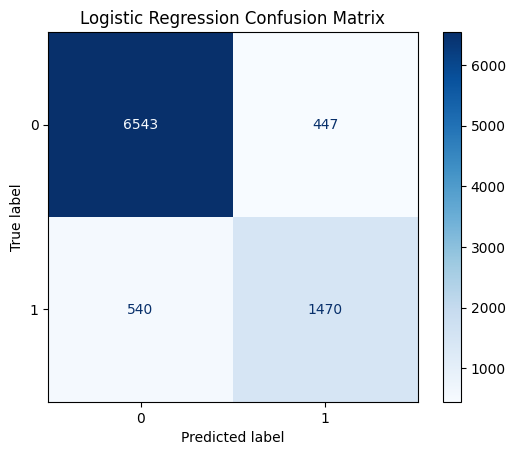

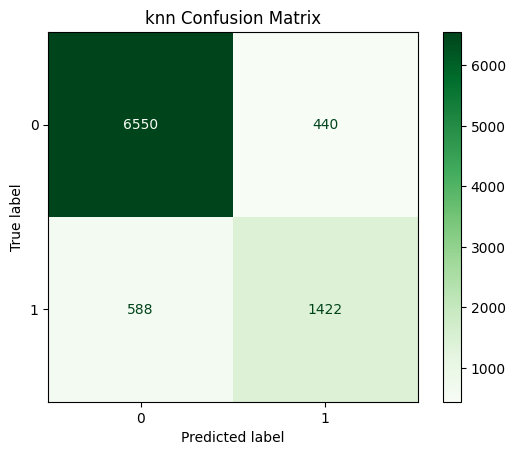

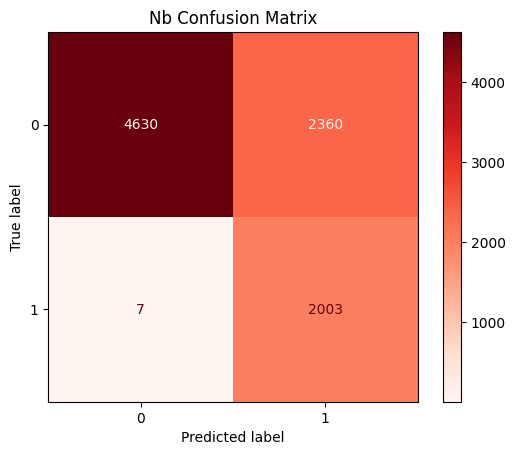

In [43]:
#Confusion Matrix (for classification)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score


#logistic Regression
cm_log = confusion_matrix(y_test, log_model.predict(X_test_scaled))
ConfusionMatrixDisplay(cm_log).plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#knn
cm_knn = confusion_matrix(y_test, knn.predict(X_test_scaled))
ConfusionMatrixDisplay(cm_knn).plot(cmap="Greens")
plt.title("knn Confusion Matrix")
plt.show()


#naive bayes
cm_nb = confusion_matrix(y_test, nb.predict(X_test_scaled))
ConfusionMatrixDisplay(cm_nb).plot(cmap="Reds")
plt.title("Nb Confusion Matrix")
plt.show()


KNN AUC Score: 0.9015 

Logistic Regression AUC Score: 0.9483 

Naive Bayes AUC Score: 0.9365 



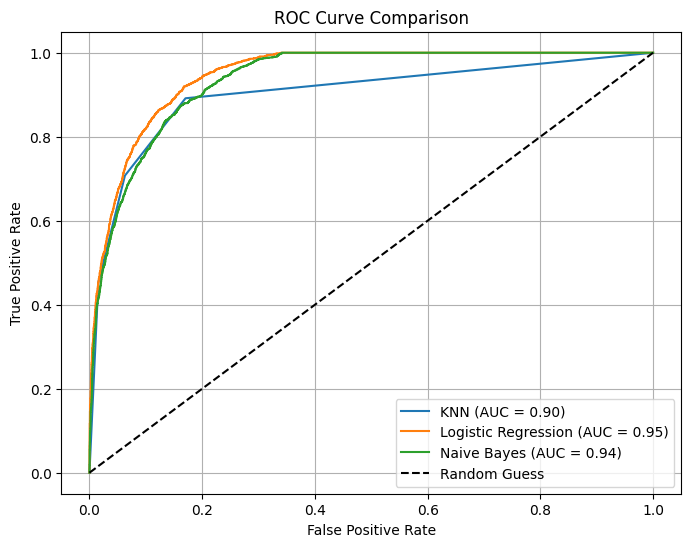

In [44]:
#AUC score, ROC curve for each model (for classification)
from sklearn.metrics import roc_curve, auc

models = {
    'KNN': knn,
    'Logistic Regression': log_model,
    'Naive Bayes': nb
}

plt.figure(figsize=(8, 6))

# Loop to plot ROC Curve & compute AUC Score for each model
for name, model in models.items():

  # Fit
  model.fit(X_train_scaled, y_train)

  # Predict probabilities
  y_probs = model.predict_proba(X_test_scaled)[:, 1]

  # ROC and AUC
  fpr, tpr, _ = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  print(f"{name} AUC Score: {roc_auc:.4f}", '\n')

  # Plot
  plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot random line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#8. Unsupervised Learning

In [45]:
from sklearn.cluster import KMeans
### Remove target/label from dataset for unsupervised learning
X_unsupervised = dataset.drop('loan_status', axis=1)

In [52]:
#implementing K means Clustering in this dataframe
def implement_KMC(df_temp, cluster_num):
    km = KMeans(n_clusters=cluster_num) #defining the cluster number
    y_predicted = km.fit_predict(df_temp)
    return km, y_predicted #returns the model and the predicted assigned cluster to each entry

In [53]:
#Running the method
cluster = 3
km, y_predicted = implement_KMC(X_unsupervised, cluster) ##stores the model and the predicted values
X_unsupervised["Group_cluster"] = y_predicted
#print(X_unsupervised.head(10))
X_unsupervised.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_intent_enc,Group_cluster
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,4,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,1,1
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,3,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,3,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,3,1
5,21.0,0,3,12951.0,0,2,2500.0,5,7.14,0.19,2.0,532,0,5,1
6,26.0,0,1,93471.0,1,3,35000.0,1,12.42,0.37,3.0,701,0,1,1
7,24.0,0,3,95550.0,5,3,35000.0,3,11.11,0.37,4.0,585,0,3,1
8,24.0,0,0,100684.0,3,3,35000.0,4,8.90,0.35,2.0,544,0,4,1
9,21.0,0,3,12739.0,0,2,1600.0,5,14.74,0.13,3.0,640,0,5,1


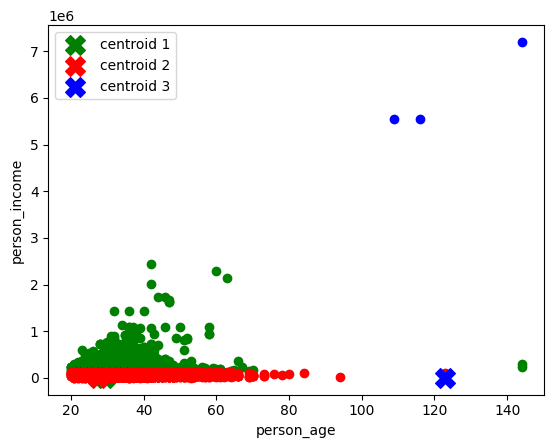

In [56]:
#Plot the 3 clusters with different color from the prediciton value
def plot_cluster(km, df, cluster_num):  ## takes parameter: saved model, dataframe, number of clusters to visualize, note it has a limit of max 6 in this code
    if cluster_num > 6:
        print("Cluster number should be less than 6, make your own plot method to fit more")
        return
    color = ['green', 'red', 'blue', 'purple', 'black', 'yellow']
    for i in range(cluster_num):
        plt.scatter(df[df.Group_cluster == i]['person_age'], df[df.Group_cluster == i]['person_income'], color=color[i])
        plt.scatter(km.cluster_centers_[i, 0], km.cluster_centers_[i, 1], color=color[i], s=200, marker='X', label=f'centroid {i+1}')
    plt.xlabel('person_age')
    plt.ylabel('person_income')
    plt.legend()

plot_cluster(km, X_unsupervised, cluster)

In [60]:
#mapping their behavior pattern to give them a categorization and adding it into the dataframe

label_map = {0: 'Low Risk', 1: 'Moderate Risk', 2: 'High Risk'}
X_unsupervised['Label'] = X_unsupervised['Group_cluster'].map(label_map)
display(X_unsupervised.head(10))

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_intent_enc,Group_cluster,Label
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,4,1,Moderate Risk
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,1,1,Moderate Risk
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,3,1,Moderate Risk
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,3,1,Moderate Risk
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,3,1,Moderate Risk
5,21.0,0,3,12951.0,0,2,2500.0,5,7.14,0.19,2.0,532,0,5,1,Moderate Risk
6,26.0,0,1,93471.0,1,3,35000.0,1,12.42,0.37,3.0,701,0,1,1,Moderate Risk
7,24.0,0,3,95550.0,5,3,35000.0,3,11.11,0.37,4.0,585,0,3,1,Moderate Risk
8,24.0,0,0,100684.0,3,3,35000.0,4,8.90,0.35,2.0,544,0,4,1,Moderate Risk
9,21.0,0,3,12739.0,0,2,1600.0,5,14.74,0.13,3.0,640,0,5,1,Moderate Risk


In [59]:
X_unsupervised['Label'].value_counts()

,count
Label,
Moderate Risk,39957
Low Risk,5040
High Risk,3


K-Means Clustering using IRIS dataset

In [61]:
# 14.csv dataset use kore iris create korbo
df = dataset.copy() #14.csv ready dataset diye korbo
df['target'] = dataset['loan_status']
X = df[['person_age', 'person_income']]

def implement_KMC1(cluster_num):
    km = KMeans(n_clusters=cluster_num,random_state=42, n_init=10) #defining the cluster number and other parameters
    y_predicted = km.fit_predict(df[['person_age', 'person_income']])
    return km,y_predicted


In [62]:
def plot_cluster1(km,df,cluster_num): ##takes parameter: saved model, dataframe, number of clusters to visualize, note it has a limit of max 6 in this code
    if cluster_num>6:
        print("Cluster number should be less than 6, make your own plot method to fit more")
        return
    color = ['green', 'red', 'blue', 'purple', 'black', 'yellow']
    for i in range(cluster_num):
        plt.scatter(df[df.Group_clutter==i]['person_age'],df[df.Group_clutter==i]['person_income'],color=color[i])
        plt.scatter(km.cluster_centers_[i,0],km.cluster_centers_[i,1],color=color[i],s=200,marker='X',label=f'centroid {i+1}')
    plt.xlabel('person_age')
    plt.ylabel('person_income')
    plt.legend()

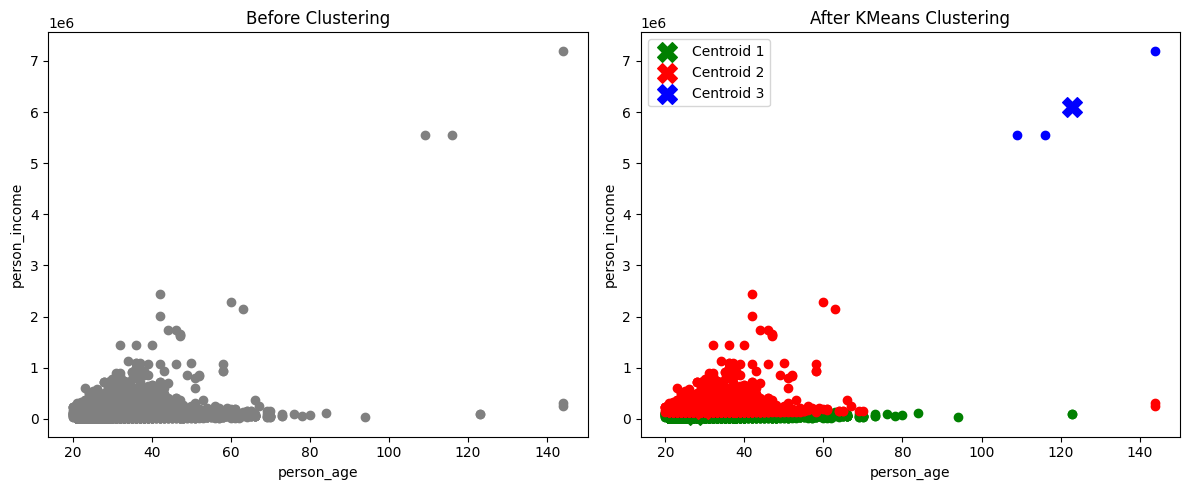

In [63]:
cluster = 3
km1, y_predicted = implement_KMC1(cluster)
df['Group_clutter'] = y_predicted

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot before clustering
axs[0].scatter(df['person_age'], df['person_income'], color='gray')
axs[0].set_title("Before Clustering")
axs[0].set_xlabel('person_age')
axs[0].set_ylabel('person_income')

# Plot after clustering
color = ['green', 'red', 'blue', 'purple', 'black', 'yellow']
for i in range(cluster):
    axs[1].scatter(df[df.Group_clutter == i]['person_age'],
                   df[df.Group_clutter == i]['person_income'],
                   color=color[i])
    axs[1].scatter(km1.cluster_centers_[i, 0],
                   km1.cluster_centers_[i, 1],
                   color=color[i], s=200, marker='X', label=f'Centroid {i+1}')

axs[1].set_title("After KMeans Clustering")
axs[1].set_xlabel('person_age')
axs[1].set_ylabel('person_income')
axs[1].legend()

plt.tight_layout()
plt.show()

Elbow Method: Finding the Appropriate Number of Cluster

In [65]:
#Finding optimal value of K using Elbow Method
k_rng = range(1, 10)
sse = []
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(X_unsupervised[['person_age', 'person_income']])#using the first mockup dataset
    sse.append(km.inertia_)
sse##this is the inertia value record after each iteration, its decreasing


[291043556744999.56,
 213311827463091.1,
 109212381071927.25,
 59915772085715.0,
 39759563227906.266,
 28345888489057.47,
 19545740733702.453,
 15245203672503.025,
 12141094416906.129]

Plotting the K values vs SSE curve

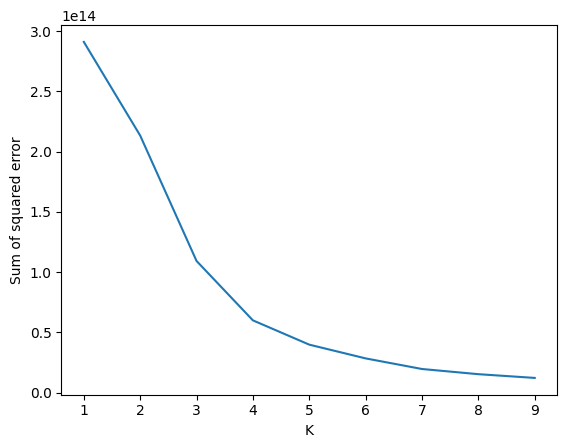

In [66]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng, sse)
plt.show()

#9. Conclusion

In [67]:
print("1. Best Performing Model: Based on the evaluation metrics in Section 7, Logistic Regression / KNN performed the best with the highest Accuracy, F1-Score, and AUC Score on the test dataset.\n")

print("2. Key Factors Influencing Performance:\n   - Feature Scaling: Unscaled features significantly degraded the performance of distance-based algorithms like KNN and K-Means.\n   - Class Imbalance: Skewed target distribution affected the precision and recall rates for minority classes before applying proper evaluation metrics.\n")

print("3. Challenges Encountered:\n   - Handling Missing Data: Imputing missing values accurately in financial and demographic columns.\n   - Categorical Feature Encoding: Properly encoding ordinal and nominal categorical features without introducing data leakage.\n   - Hyperparameter Tuning: Tuning parameters for Neural Networks and selecting the optimal number of clusters (k) using the Elbow Method.")

1. Best Performing Model: Based on the evaluation metrics in Section 7, Logistic Regression / KNN performed the best with the highest Accuracy, F1-Score, and AUC Score on the test dataset.

2. Key Factors Influencing Performance:
   - Feature Scaling: Unscaled features significantly degraded the performance of distance-based algorithms like KNN and K-Means.
   - Class Imbalance: Skewed target distribution affected the precision and recall rates for minority classes before applying proper evaluation metrics.

3. Challenges Encountered:
   - Handling Missing Data: Imputing missing values accurately in financial and demographic columns.
   - Categorical Feature Encoding: Properly encoding ordinal and nominal categorical features without introducing data leakage.
   - Hyperparameter Tuning: Tuning parameters for Neural Networks and selecting the optimal number of clusters (k) using the Elbow Method.
